# Optimisation de portefeuille CAC40 par SGD — Étude empirique

**Projet d'extension — Descente de gradient stochastique appliquée à la gestion de portefeuille**

---

## Structure du notebook

| Section | Contenu |
|---------|---------|
| 0 | Configuration et chargement des données |
| 1 | Analyse exploratoire (EDA) |
| 2 | Estimation des paramètres de marché |
| 3 | Référence analytique de Markowitz |
| 4 | Optimisation par SGD (avec actif sans risque) |
| 5 | Extension Machine Learning (modèle linéaire + softmax) |
| 6 | Backtest et comparaison des stratégies |
| 7 | Analyse de sensibilité |
| 8 | Synthèse et conclusions |

> **Convention** : les rendements des actifs risqués sont **journaliers** ;  
> le taux sans risque `RISK_FREE_RATE` est **annuel** ; `T = 252` jours de bourse par an.


## 0. Configuration et chargement des données

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Ajouter le dossier des modules au path ──────────────────────────────────
# Adapter ce chemin si nécessaire
sys.path.append(os.path.abspath('..'))

from ext.portfolio_math import (
    estimate_expected_returns,
    estimate_covariance_matrix,
    markowitz_analytical_weights,
    portfolio_expected_return_with_cash,
    portfolio_volatility,
    compute_risk_free_weight,
    project_to_cash_simplex,
)
from ext.sgd_optimizer import (
	initialize_weights,
	run_sgd,
)
from ext.ml_signals import (
	build_ml_signals, 
	run_ml_sgd,
	)
from ext.portfolio_backtest import run_portfolio_backtest

# ── Style graphique ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
COLORS = plt.cm.tab10.colors

print("✓ Modules importés")


✓ Modules importés


In [2]:
# ── Univers d'actifs ────────────────────────────────────────────────────────
TICKERS = [
    'MC.PA',   # LVMH            — Luxe / Conso
    'RMS.PA',  # Hermès          — Luxe / Conso
    'OR.PA',   # L'Oréal         — Luxe / Conso
    'AIR.PA',  # Airbus          — Industrie
    'SAN.PA',  # Sanofi          — Santé
    'DG.PA',   # Vinci           — Industrie
    'BNP.PA',  # BNP Paribas     — Banque
    'ACA.PA',  # Crédit Agricole — Banque
    'CS.PA',   # AXA             — Assurance
    'TTE.PA',  # TotalEnergies   — Énergie
    'EN.PA',   # Bouygues        — Utilities
    'VIE.PA',  # Veolia          — Utilities
    'CAP.PA',  # Capgemini       — Tech / IT
]

RISK_FREE_RATE      = 0.03    # taux annuel
ANNUALIZATION       = 252     # jours de bourse par an
N_ASSETS            = len(TICKERS)

# ── Chargement des données ──────────────────────────────────────────────────
# Option A : données réelles via yfinance
import yfinance as yf
prices = yf.download(TICKERS, start='2018-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)['Close']
prices = prices[TICKERS].dropna(how='all')
returns = prices.pct_change().dropna()


print(f"Période   : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Actifs    : {N_ASSETS}")
print(f"Jours     : {len(returns)}")
print(f"Valeurs manquantes : {returns.isnull().sum().sum()}")
returns.describe().round(4)


Période   : 2018-01-03 → 2024-12-30
Actifs    : 13
Jours     : 1792
Valeurs manquantes : 0


Ticker,MC.PA,RMS.PA,OR.PA,AIR.PA,SAN.PA,DG.PA,BNP.PA,ACA.PA,CS.PA,TTE.PA,EN.PA,VIE.PA,CAP.PA
count,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000,1792.0000
mean,0.0008,0.0011,0.0005,0.0007,0.0004,0.0004,0.0004,0.0004,0.0005,0.0005,0.0001,0.0004,0.0005
std,0.0180,0.0163,0.0146,0.0237,0.0136,0.0174,0.0202,0.0189,0.0159,0.0181,0.0171,0.0168,0.0186
min,-0.0868,-0.0654,-0.0758,-0.2217,-0.1893,-0.1707,-0.1352,-0.1686,-0.1522,-0.1661,-0.1731,-0.1608,-0.1160
25%,-0.0090,-0.0070,-0.0075,-0.0097,-0.0069,-0.0069,-0.0089,-0.0083,-0.0063,-0.0082,-0.0075,-0.0076,-0.0092
50%,0.0010,0.0016,0.0008,0.0009,0.0003,0.0005,0.0005,0.0010,0.0009,0.0008,0.0005,0.0010,0.0005
75%,0.0100,0.0099,0.0082,0.0106,0.0076,0.0078,0.0100,0.0090,0.0076,0.0097,0.0085,0.0092,0.0102
max,0.1281,0.0910,0.0844,0.2046,0.0631,0.1885,0.1798,0.1367,0.1756,0.1507,0.1464,0.1226,0.1177


## 1. Analyse exploratoire des données (EDA)

Avant toute optimisation, on examine la distribution des rendements, les corrélations entre actifs et les statistiques descriptives.  
Ces éléments justifient les hypothèses du modèle mean-variance (rendements i.i.d., covariance stationnaire).


In [3]:
# ── 1.1 Statistiques annualisées ────────────────────────────────────────────
stats = pd.DataFrame({
    'μ annualisé'   : returns.mean() * ANNUALIZATION,
    'σ annualisée'  : returns.std(ddof=1) * np.sqrt(ANNUALIZATION),
    'Skewness'      : returns.skew(),
    'Kurtosis'      : returns.kurtosis(),
    'Min journalier': returns.min(),
    'Max journalier': returns.max(),
}).round(4)

stats['Sharpe ex-ante'] = (
    (stats['μ annualisé'] - RISK_FREE_RATE) / stats['σ annualisée']
).round(3)

print("=== Statistiques descriptives annualisées ===")
stats.sort_values('Sharpe ex-ante', ascending=False)


=== Statistiques descriptives annualisées ===


,μ annualisé,σ annualisée,Skewness,Kurtosis,Min journalier,Max journalier,Sharpe ex-ante
Ticker,,,,,,,
RMS.PA,0.2744,0.2582,0.1181,3.1199,-0.0654,0.0910,0.947
MC.PA,0.1911,0.2857,0.2929,4.1690,-0.0868,0.1281,0.564
OR.PA,0.1279,0.2316,0.2397,4.1692,-0.0758,0.0844,0.423
CS.PA,0.1326,0.2516,0.0417,20.5144,-0.1522,0.1756,0.408
AIR.PA,0.1696,0.3769,0.1537,15.9827,-0.2217,0.2046,0.370
SAN.PA,0.0996,0.2160,-1.5520,23.4184,-0.1893,0.0631,0.322
CAP.PA,0.1224,0.2959,0.2346,5.0357,-0.1160,0.1177,0.312
VIE.PA,0.1116,0.2662,-0.4178,8.7957,-0.1608,0.1226,0.307
TTE.PA,0.1178,0.2877,-0.2291,14.8024,-0.1661,0.1507,0.305


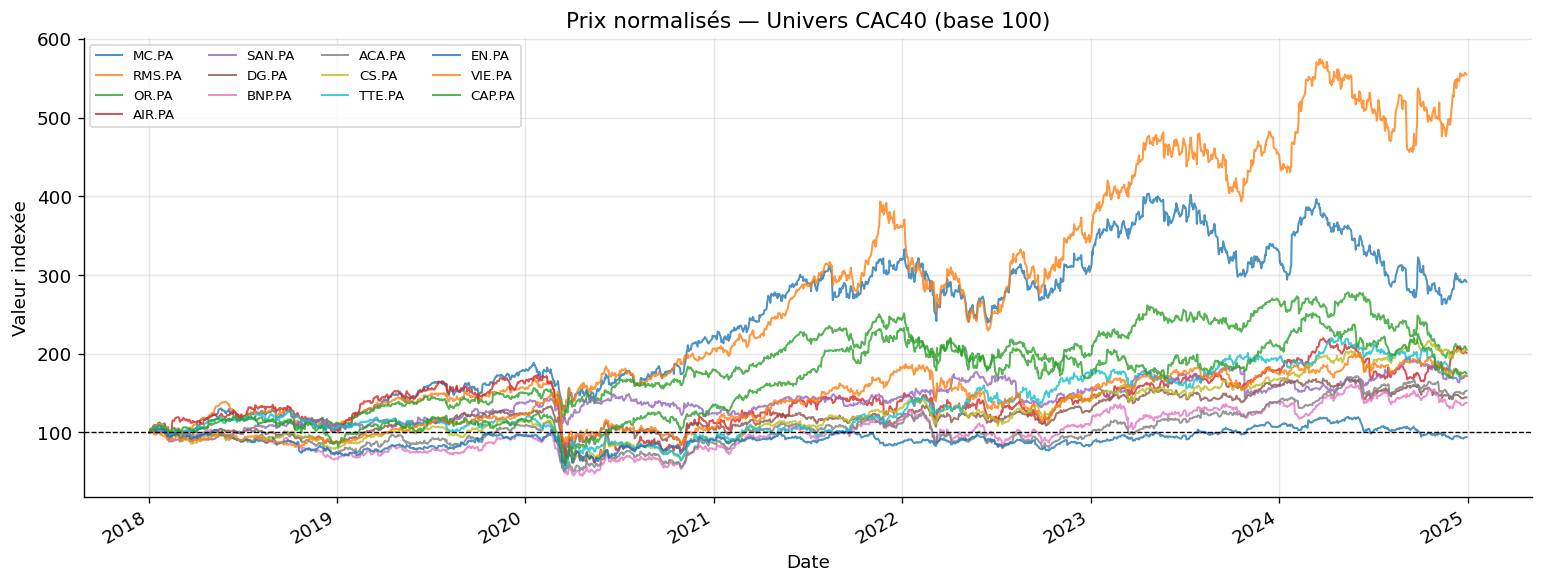

In [4]:
# ── 1.2 Prix cumulés normalisés (base 100) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
(prices / prices.iloc[0] * 100).plot(ax=ax, alpha=0.8, linewidth=1.2)
ax.axhline(100, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Prix normalisés — Univers CAC40 (base 100)", fontsize=13)
ax.set_ylabel("Valeur indexée")
ax.legend(TICKERS, ncol=4, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()


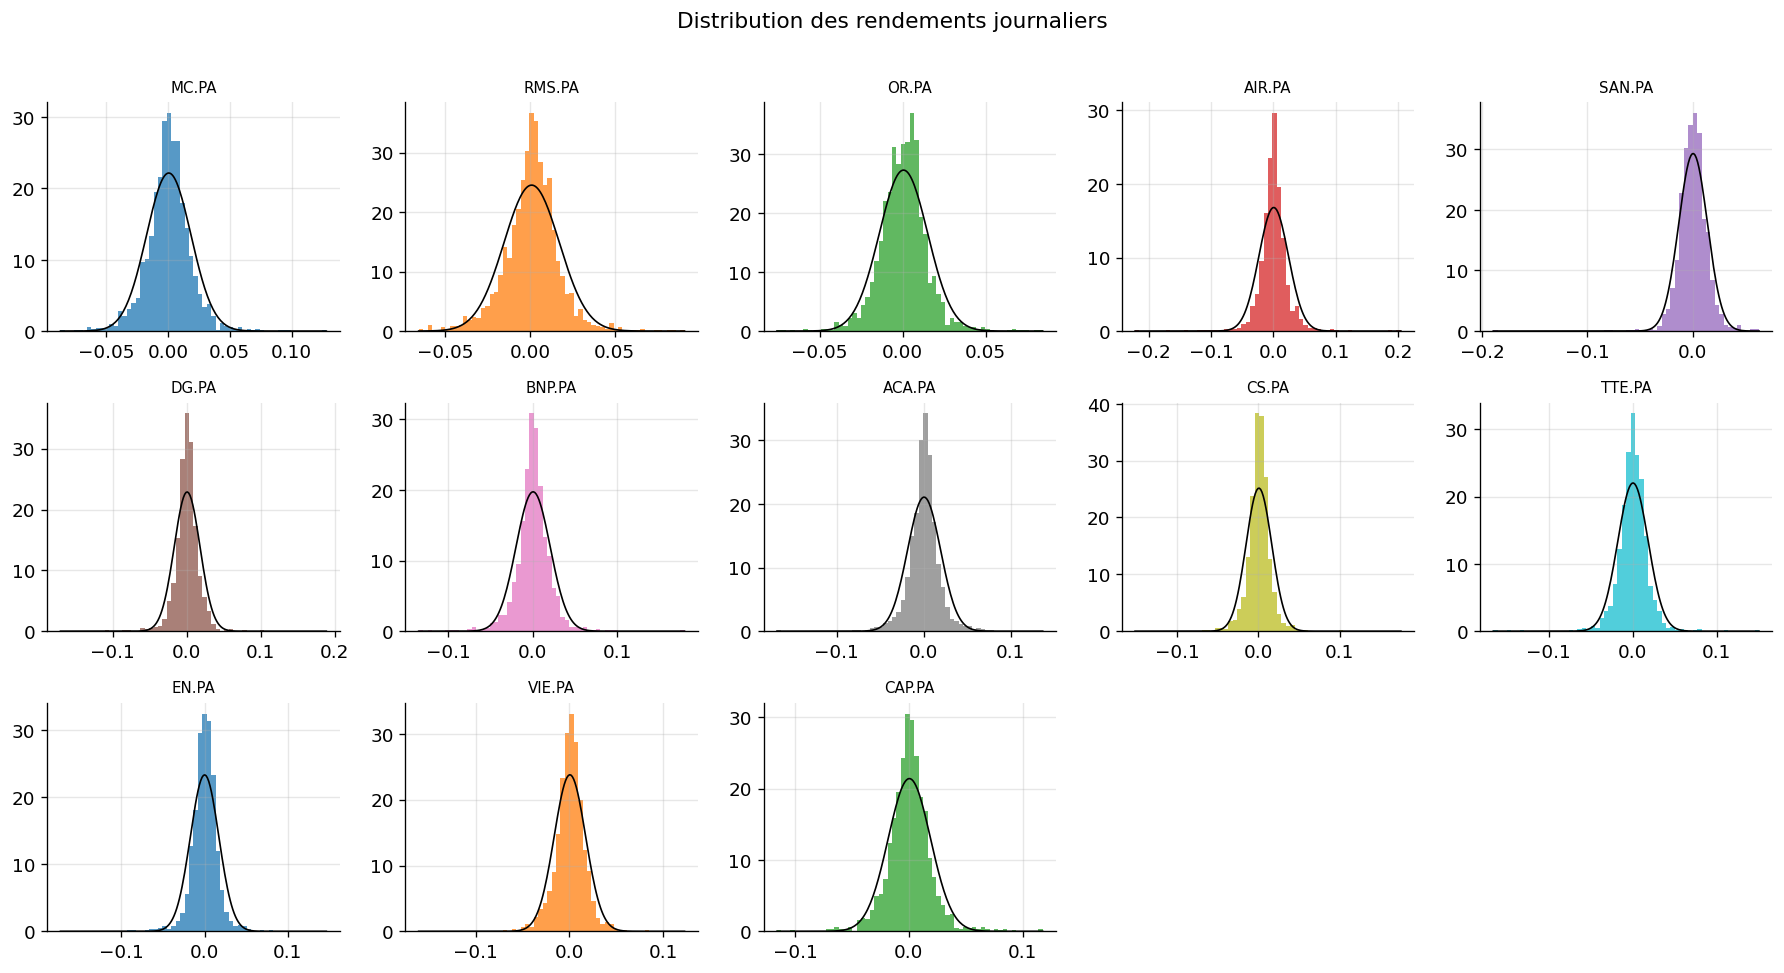

Remarque : les queues épaisses (kurtosis > 0) sont visibles pour plusieurs actifs.
Cela constitue une limite connue du modèle mean-variance (hypothèse gaussienne).


In [5]:
# ── 1.3 Distribution des rendements journaliers ────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(15, 8), sharex=False)
axes = axes.flatten()
for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    r = returns[ticker].dropna()
    ax.hist(r, bins=60, color=COLORS[i % 10], alpha=0.75, density=True, edgecolor='none')
    # Gaussienne théorique
    x = np.linspace(r.min(), r.max(), 200)
    from scipy.stats import norm
    ax.plot(x, norm.pdf(x, r.mean(), r.std()), 'k-', linewidth=1)
    ax.set_title(ticker, fontsize=9)
    ax.set_xlabel("")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Distribution des rendements journaliers", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("Remarque : les queues épaisses (kurtosis > 0) sont visibles pour plusieurs actifs.")
print("Cela constitue une limite connue du modèle mean-variance (hypothèse gaussienne).")


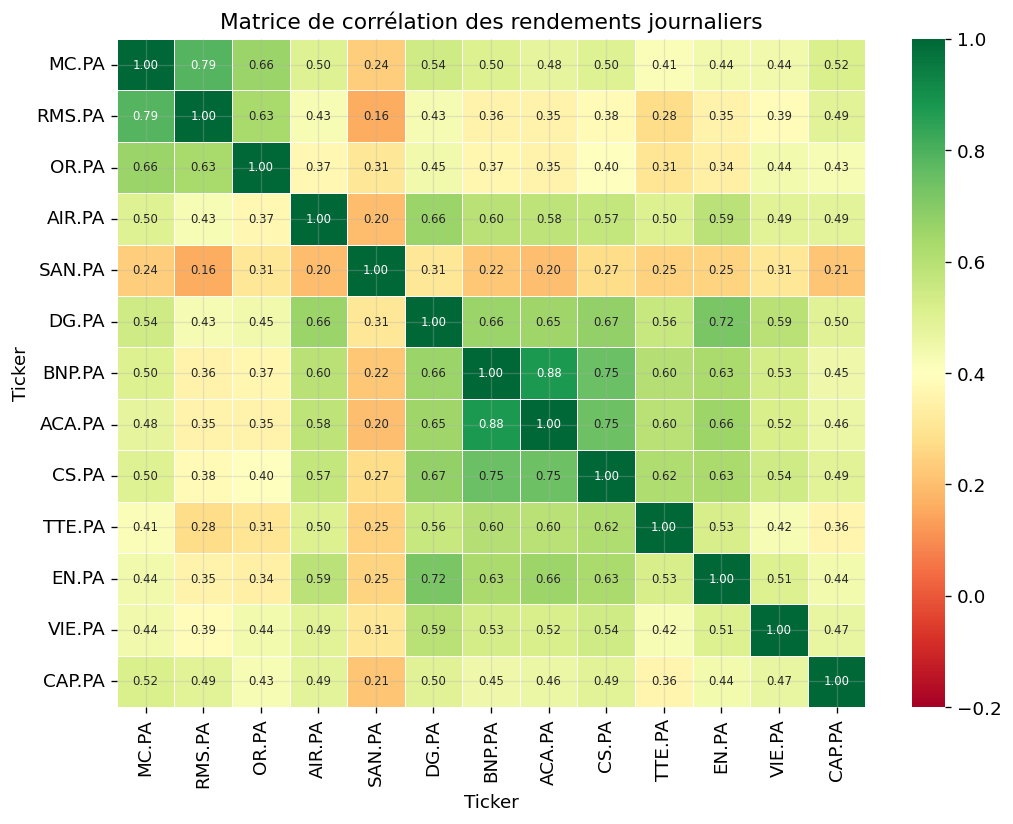

Corrélation moyenne inter-actifs : 0.473


In [6]:
# ── 1.4 Matrice de corrélation ─────────────────────────────────────────────
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn',
    vmin=-0.2, vmax=1.0, linewidths=0.5,
    ax=ax, annot_kws={"size": 7}
)
ax.set_title("Matrice de corrélation des rendements journaliers", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Corrélation moyenne inter-actifs : {corr_matrix.values[np.triu_indices(N_ASSETS, k=1)].mean():.3f}")


## 2. Estimation des paramètres de marché

On estime les paramètres µ et Σ sur l'**ensemble d'entraînement** (2018–2022),  
et on réserve 2023–2024 pour le **backtest out-of-sample**.

$$\hat{\mu} = \frac{1}{T}\sum_{t=1}^T r_t \qquad \hat{\Sigma} = \frac{1}{T-1}\sum_{t=1}^T (r_t - \hat{\mu})(r_t - \hat{\mu})^\top$$


In [7]:
# ── Split train / test ──────────────────────────────────────────────────────
TRAIN_END = '2022-12-31'
TEST_START = '2023-01-01'

returns_train = returns.loc[:TRAIN_END]
returns_test  = returns.loc[TEST_START:]
prices_test   = prices.loc[TEST_START:]

print(f"Train : {returns_train.index[0].date()} → {returns_train.index[-1].date()} ({len(returns_train)} jours)")
print(f"Test  : {returns_test.index[0].date()}  → {returns_test.index[-1].date()} ({len(returns_test)} jours)")

# ── Estimation sur train ────────────────────────────────────────────────────
R_train = returns_train.to_numpy()
mu_hat  = estimate_expected_returns(R_train)       # journalier
Sigma_hat = estimate_covariance_matrix(R_train, shrinkage=0.05)  # shrinkage léger

print(f"\nμ̂ journalier   : min={mu_hat.min():.5f}, max={mu_hat.max():.5f}")
print(f"Σ̂ conditionnement : {np.linalg.cond(Sigma_hat):.1f}")
print(f"Sigma est définie positive : {np.all(np.linalg.eigvalsh(Sigma_hat) > 0)}")


Train : 2018-01-03 → 2022-12-30 (1282 jours)
Test  : 2023-01-02  → 2024-12-30 (510 jours)

μ̂ journalier   : min=0.00003, max=0.00109
Σ̂ conditionnement : 44.6
Sigma est définie positive : True


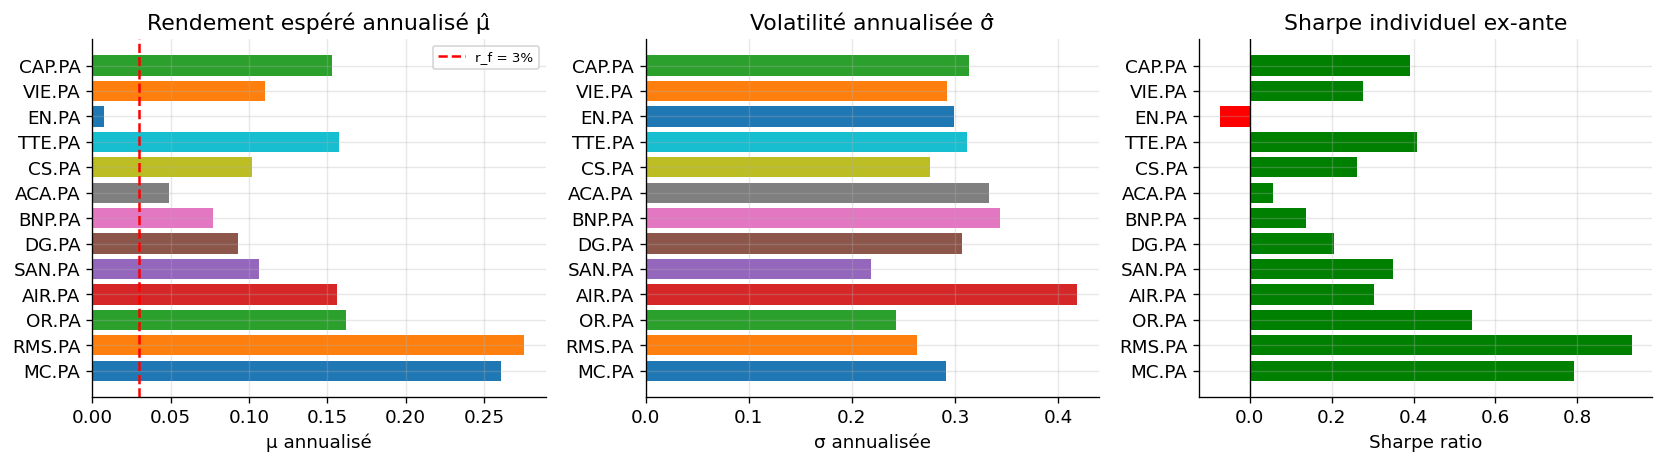

In [8]:
# ── Visualisation de μ et σ annualisés ──────────────────────────────────────
mu_ann  = mu_hat * ANNUALIZATION
vol_ann = np.sqrt(np.diag(Sigma_hat)) * np.sqrt(ANNUALIZATION)
sharpe_indiv = (mu_ann - RISK_FREE_RATE) / vol_ann

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].barh(TICKERS, mu_ann, color=COLORS[:N_ASSETS])
axes[0].axvline(RISK_FREE_RATE, color='red', linestyle='--', label=f'r_f = {RISK_FREE_RATE:.0%}')
axes[0].set_title("Rendement espéré annualisé μ̂")
axes[0].set_xlabel("μ annualisé")
axes[0].legend(fontsize=8)

axes[1].barh(TICKERS, vol_ann, color=COLORS[:N_ASSETS])
axes[1].set_title("Volatilité annualisée σ̂")
axes[1].set_xlabel("σ annualisée")

axes[2].barh(TICKERS, sharpe_indiv, color=[
    'green' if s > 0 else 'red' for s in sharpe_indiv
])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title("Sharpe individuel ex-ante")
axes[2].set_xlabel("Sharpe ratio")

plt.tight_layout()
plt.show()


## 3. Référence analytique — Solution de Markowitz

La solution analytique du problème mean-variance sans contrainte long-only est :

$$w^* = \frac{1}{2\lambda} \Sigma^{-1}(\hat{\mu} - \nu \mathbf{1}), \quad \nu = \frac{\mathbf{1}^\top \Sigma^{-1}\hat{\mu} - 2\lambda}{\mathbf{1}^\top \Sigma^{-1}\mathbf{1}}$$

Note : le facteur $T$ (annualisation) **disparaît** des conditions de premier ordre et n'influence pas $w^*$.  
Cette solution sert de **référence de convergence** pour le SGD.


In [9]:
LAMBDA = 2.0   # aversion au risque

# ── Solution analytique sans contrainte long-only ───────────────────────────
w_markowitz_free = markowitz_analytical_weights(
    expected_returns=mu_hat,
    covariance_matrix=Sigma_hat,
    lambda_risk=LAMBDA,
    nonnegative=False,
)

# ── Solution analytique avec projection simplex (approximation) ─────────────
w_markowitz_lo = markowitz_analytical_weights(
    expected_returns=mu_hat,
    covariance_matrix=Sigma_hat,
    lambda_risk=LAMBDA,
    nonnegative=True,
)

print("=== Poids Markowitz (sans contrainte long-only) ===")
for t, w in zip(TICKERS, w_markowitz_free):
    print(f"  {t:8s}: {w:+.4f}")
print(f"  sum(w) = {w_markowitz_free.sum():.6f}")

print("\n=== Poids Markowitz (projeté simplex, long-only) ===")
for t, w in zip(TICKERS, w_markowitz_lo):
    print(f"  {t:8s}: {w:.4f}")
print(f"  sum(w) = {w_markowitz_lo.sum():.6f}")


=== Poids Markowitz (sans contrainte long-only) ===
  MC.PA   : +0.3636
  RMS.PA  : +0.8642
  OR.PA   : -0.1336
  AIR.PA  : +0.0530
  SAN.PA  : +0.3111
  DG.PA   : -0.1241
  BNP.PA  : +0.0103
  ACA.PA  : -0.3263
  CS.PA   : +0.1448
  TTE.PA  : +0.4004
  EN.PA   : -0.5355
  VIE.PA  : +0.0124
  CAP.PA  : -0.0403
  sum(w) = 1.000000

=== Poids Markowitz (projeté simplex, long-only) ===
  MC.PA   : 0.1288
  RMS.PA  : 0.6293
  OR.PA   : 0.0000
  AIR.PA  : 0.0000
  SAN.PA  : 0.0762
  DG.PA   : 0.0000
  BNP.PA  : 0.0000
  ACA.PA  : 0.0000
  CS.PA   : 0.0000
  TTE.PA  : 0.1656
  EN.PA   : 0.0000
  VIE.PA  : 0.0000
  CAP.PA  : 0.0000
  sum(w) = 1.000000


In [10]:
# ── Métriques ex-ante des solutions analytiques ────────────────────────────
def print_portfolio_metrics(label, w, mu, Sigma, rf, T=252, allow_cash=False, long_only=False):
    """
    Affiche les métriques ex-ante annualisées.

    Cas 1 — Markowitz libre :
        - poids possiblement négatifs
        - portefeuille entièrement investi dans les actifs risqués
        - pas de cash explicite
        - sum(w) ≈ 1 normalement

    Cas 2 — Long-only sans cash :
        - poids positifs
        - sum(w) ≈ 1
        - w_rf = 0

    Cas 3 — Portefeuille avec cash :
        - poids positifs
        - sum(w) <= 1
        - w_rf = 1 - sum(w)
    """
    w = np.asarray(w, dtype=float)

    if allow_cash:
        # Cas SGD / portefeuille avec actif sans risque résiduel
        w_risk = np.clip(w, 0.0, None)

        if w_risk.sum() > 1.0 + 1e-6:
            w_risk = project_to_cash_simplex(w_risk)

        w_rf = compute_risk_free_weight(w_risk)

        mu_p = portfolio_expected_return_with_cash(
            w_risk,
            mu,
            w_rf=w_rf,
            risk_free_rate=rf,
            annualization_factor=T,
            annualized=True,
        )

        vol_p = portfolio_volatility(w_risk, Sigma) * np.sqrt(T)

    else:
        # Cas Markowitz analytique : pas de cash explicite
        # On ne clippe surtout pas Markowitz libre, sinon on détruit la solution.
        w_risk = w
        w_rf = 0.0

        mu_p = T * float(w_risk @ mu)
        vol_p = portfolio_volatility(w_risk, Sigma) * np.sqrt(T)

    sr = (mu_p - rf) / vol_p if vol_p > 1e-10 else 0.0

    print(
        f"  {label:40s} | "
        f"μ_p={mu_p:.3f} | "
        f"σ_p={vol_p:.3f} | "
        f"SR={sr:.3f} | "
        f"sum(w)={w_risk.sum():.4f} | "
        f"w_rf={w_rf:.4f}"
    )


print("=== Métriques ex-ante des solutions analytiques ===")

print_portfolio_metrics(
    "Markowitz libre",
    w_markowitz_free,
    mu_hat,
    Sigma_hat,
    RISK_FREE_RATE,
    allow_cash=False,
)

print_portfolio_metrics(
    "Markowitz long-only",
    w_markowitz_lo,
    mu_hat,
    Sigma_hat,
    RISK_FREE_RATE,
    allow_cash=False,
)
print("=== Métriques ex-ante (annualisées) ===")
print_portfolio_metrics("Markowitz libre",   w_markowitz_free, mu_hat, Sigma_hat, RISK_FREE_RATE)
print_portfolio_metrics("Markowitz long-only", w_markowitz_lo, mu_hat, Sigma_hat, RISK_FREE_RATE)


=== Métriques ex-ante des solutions analytiques ===
  Markowitz libre                          | μ_p=0.395 | σ_p=0.305 | SR=1.197 | sum(w)=1.0000 | w_rf=0.0000
  Markowitz long-only                      | μ_p=0.241 | σ_p=0.222 | SR=0.951 | sum(w)=1.0000 | w_rf=0.0000
=== Métriques ex-ante (annualisées) ===
  Markowitz libre                          | μ_p=0.395 | σ_p=0.305 | SR=1.197 | sum(w)=1.0000 | w_rf=0.0000
  Markowitz long-only                      | μ_p=0.241 | σ_p=0.222 | SR=0.951 | sum(w)=1.0000 | w_rf=0.0000


## 4. Optimisation par SGD avec actif sans risque

### Algorithme : gradient projeté avec ré-estimation stochastique des paramètres

À l'itération $k$ :

1. Tirer un mini-batch $\mathcal{B}_k$ de taille $B$ sans remise
2. Estimer $\hat{\mu}_{\mathcal{B}}$, $\hat{\Sigma}_{\mathcal{B}}$ sur $\mathcal{B}_k$
3. Calculer le gradient stochastique :  
   $g_k = T(2\lambda \hat{\Sigma}_{\mathcal{B}} w_k - \hat{\mu}_{\mathcal{B}}) + r_f \mathbf{1}$
4. Mise à jour : $w_{k+1} = \Pi_{\mathcal{C}}(w_k - \eta_k g_k)$

où $\Pi_{\mathcal{C}}$ est la projection sur $\mathcal{C} = \{w \geq 0, \sum w \leq 1\}$.

> **Note** : ce n'est pas un SGD au sens strict (la fonction objectif n'est pas une somme de pertes individuelles). Le bruit d'estimation sur $\hat{\mu}_{\mathcal{B}}$ et $\hat{\Sigma}_{\mathcal{B}}$ joue le rôle du bruit stochastique.


In [11]:
# ── Paramètres SGD ──────────────────────────────────────────────────────────
SGD_PARAMS = dict(
    n_iterations       = 30000,
    learning_rate      = 2e-2,
    lr_schedule        = "constant",
    lambda_risk        = LAMBDA,
    risk_free_rate     = RISK_FREE_RATE,
    use_cash           = True,
    batch_size         = len(R_train),   # important : full batch
    batch_shrinkage    = 0.0,
    nonnegative        = True,
    exact_simplex      = True,
    annualization_factor = ANNUALIZATION,
    convergence_tolerance = 1e-7,
    convergence_window    = 50,
    eval_every         = 1,
    random_state       = 42,
    verbose            = False,
)

# ── Initialisation équipondérée ─────────────────────────────────────────────
w0 = initialize_weights(N_ASSETS, method="equal", risky_budget=0.8)
print(f"w0 : sum={w0.sum():.4f}, w_rf={1-w0.sum():.4f}")

# ── Lancement du SGD ────────────────────────────────────────────────────────
print("\nLancement du SGD...")
sgd_result = run_sgd(
    returns_matrix  = R_train,
    initial_weights = w0,
    **SGD_PARAMS,
)

w_sgd = sgd_result['final_weights']
w_rf_sgd = sgd_result['w_rf']

print(f"\n✓ SGD terminé — {sgd_result['n_iterations']} itérations")
print(f"  Arrêt empirique détecté : {sgd_result['converged']}")
print(f"  Schedule utilisé        : {sgd_result['lr_schedule']}")
print(f"\nPoids finaux (actifs risqués) :")
for t, w in zip(TICKERS, w_sgd):
    print(f"  {t:8s}: {w:.4f}")
print(f"  w_rf    : {w_rf_sgd:.4f}  (actif sans risque)")
print(f"  sum(w)  : {w_sgd.sum():.6f}")


w0 : sum=0.8000, w_rf=0.2000

Lancement du SGD...

✓ SGD terminé — 3495 itérations
  Arrêt empirique détecté : True
  Schedule utilisé        : constant

Poids finaux (actifs risqués) :
  MC.PA   : 0.0706
  RMS.PA  : 0.7612
  OR.PA   : 0.0000
  AIR.PA  : 0.0000
  SAN.PA  : 0.1256
  DG.PA   : 0.0000
  BNP.PA  : 0.0000
  ACA.PA  : 0.0000
  CS.PA   : 0.0000
  TTE.PA  : 0.0426
  EN.PA   : 0.0000
  VIE.PA  : 0.0000
  CAP.PA  : 0.0000
  w_rf    : 0.0000  (actif sans risque)
  sum(w)  : 1.000000


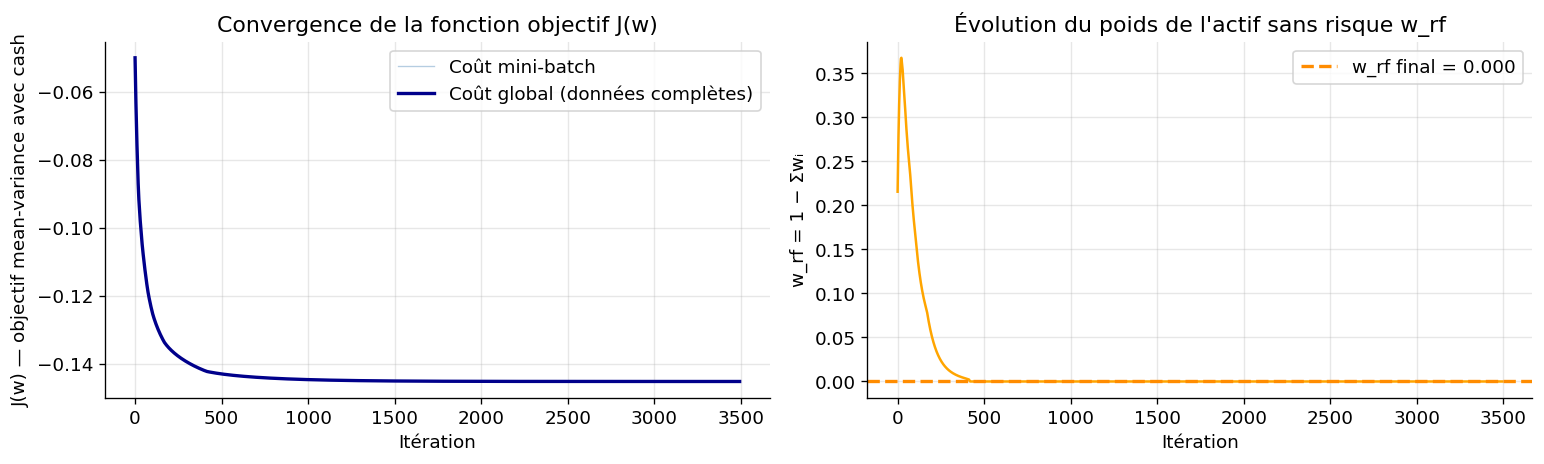

In [12]:
# ── Courbe de convergence ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Coût mini-batch
cost_batch = sgd_result['cost_history']
axes[0].plot(cost_batch, alpha=0.4, linewidth=0.8, color='steelblue', label='Coût mini-batch')

# Coût sur données complètes (tous les eval_every pas)
full_iters = sgd_result['full_cost_iters']
full_costs = sgd_result['full_cost_history']
axes[0].plot(full_iters, full_costs, color='darkblue', linewidth=2, label='Coût global (données complètes)')
axes[0].set_title("Convergence de la fonction objectif J(w)")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("J(w) — objectif mean-variance avec cash")
axes[0].legend()

# Évolution du poids cash
w_rf_hist = sgd_result['w_rf_history']
axes[1].plot(w_rf_hist, color='orange', linewidth=1.5)
axes[1].axhline(w_rf_sgd, color='darkorange', linestyle='--', linewidth=2, label=f"w_rf final = {w_rf_sgd:.3f}")
axes[1].set_title("Évolution du poids de l'actif sans risque w_rf")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("w_rf = 1 − Σwᵢ")
axes[1].legend()

plt.tight_layout()
plt.show()


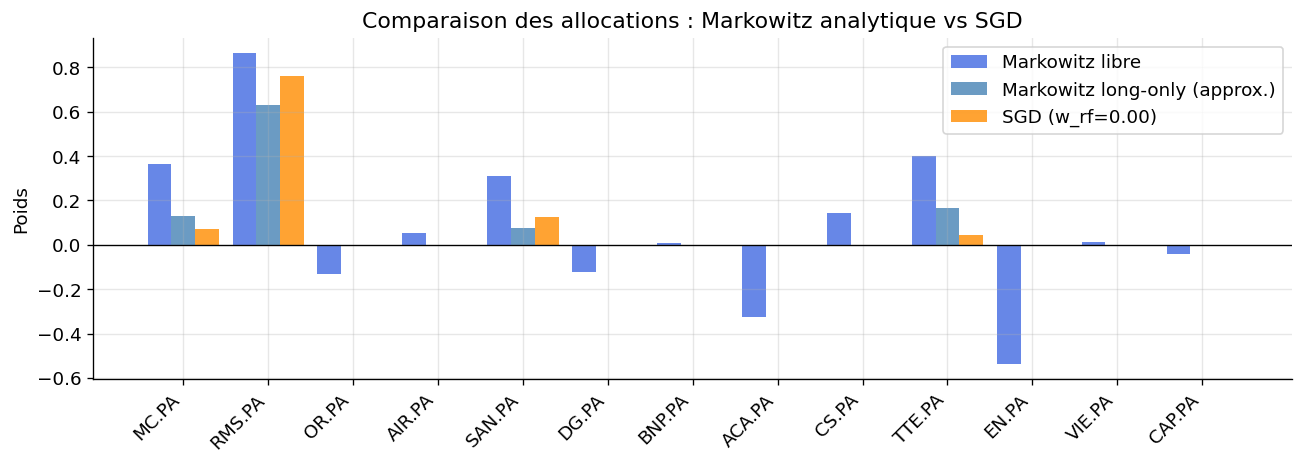

=== Métriques ex-ante (annualisées, train) ===
  Markowitz libre                          | μ_p=0.395 | σ_p=0.305 | SR=1.197 | sum(w)=1.0000 | w_rf=0.0000
  Markowitz long-only                      | μ_p=0.241 | σ_p=0.222 | SR=0.951 | sum(w)=1.0000 | w_rf=0.0000
  SGD (w_rf=0.00)                          | μ_p=0.248 | σ_p=0.228 | SR=0.959 | sum(w)=1.0000 | w_rf=0.0000


In [13]:
# ── Comparaison SGD vs Markowitz analytique ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(N_ASSETS)
width = 0.28

ax.bar(x - width, w_markowitz_free, width, label='Markowitz libre', alpha=0.8, color='royalblue')
ax.bar(x,          w_markowitz_lo,  width, label='Markowitz long-only (approx.)', alpha=0.8, color='steelblue')
ax.bar(x + width,  w_sgd,           width, label=f'SGD (w_rf={w_rf_sgd:.2f})', alpha=0.8, color='darkorange')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45, ha='right')
ax.set_title("Comparaison des allocations : Markowitz analytique vs SGD")
ax.set_ylabel("Poids")
ax.legend()
plt.tight_layout()
plt.show()

# Métriques
print("=== Métriques ex-ante (annualisées, train) ===")
print_portfolio_metrics("Markowitz libre",          w_markowitz_free, mu_hat, Sigma_hat, RISK_FREE_RATE)
print_portfolio_metrics("Markowitz long-only",       w_markowitz_lo,   mu_hat, Sigma_hat, RISK_FREE_RATE)
print_portfolio_metrics(f"SGD (w_rf={w_rf_sgd:.2f})", w_sgd,            mu_hat, Sigma_hat, RISK_FREE_RATE)


Optimisation pour différentes valeurs de λ...
  λ=  0.5 | w_rf=0.151 | sum(w_risk)=0.849
  λ=  1.0 | w_rf=0.178 | sum(w_risk)=0.822
  λ=  2.0 | w_rf=0.229 | sum(w_risk)=0.771
  λ=  5.0 | w_rf=0.363 | sum(w_risk)=0.637
  λ= 10.0 | w_rf=0.531 | sum(w_risk)=0.469


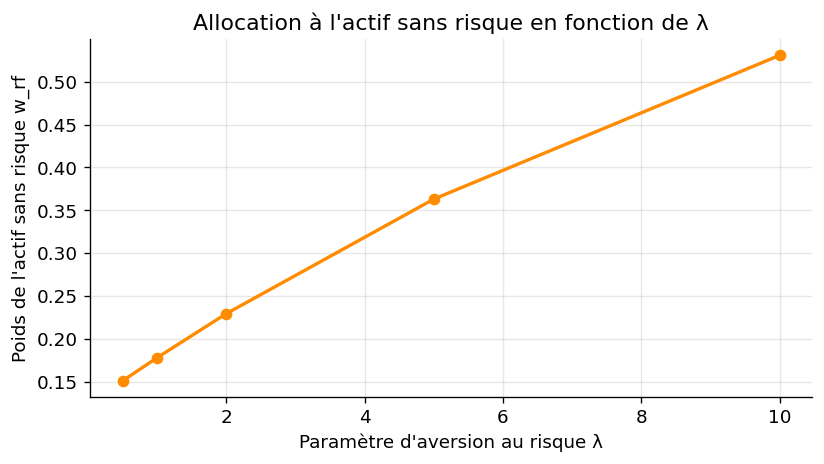

Interprétation : plus λ est grand, plus l'investisseur fuit le risque → w_rf augmente.


In [14]:
# ── Sensibilité au lambda (aversion au risque) ──────────────────────────────
lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]
sgd_results_lambda = {}

print("Optimisation pour différentes valeurs de λ...")
for lam in lambdas:
    res = run_sgd(
        returns_matrix  = R_train,
        initial_weights = initialize_weights(N_ASSETS, method="equal", risky_budget=0.8),
        n_iterations    = 800,
        learning_rate   = 1e-3,
        lr_schedule     = "sqrt",
        lambda_risk     = lam,
        risk_free_rate  = RISK_FREE_RATE,
        use_cash        = True,
        batch_size      = 64,
        batch_shrinkage = 0.05,
        nonnegative     = True,
        exact_simplex   = True,
        annualization_factor = ANNUALIZATION,
        random_state    = 42,
        verbose         = False,
    )
    sgd_results_lambda[lam] = res
    print(f"  λ={lam:5.1f} | w_rf={res['w_rf']:.3f} | sum(w_risk)={res['final_weights'].sum():.3f}")

# Visualisation de l'allocation risquée vs cash en fonction de λ
w_rf_by_lambda = [sgd_results_lambda[l]['w_rf'] for l in lambdas]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lambdas, w_rf_by_lambda, 'o-', color='darkorange', linewidth=2)
ax.set_xlabel("Paramètre d'aversion au risque λ")
ax.set_ylabel("Poids de l'actif sans risque w_rf")
ax.set_title("Allocation à l'actif sans risque en fonction de λ")
plt.tight_layout()
plt.show()
print("Interprétation : plus λ est grand, plus l'investisseur fuit le risque → w_rf augmente.")


## 5. Extension Machine Learning — Modèle linéaire avec SGD

### Architecture du modèle

À chaque date $t$ et pour chaque actif $i$, on construit un score linéaire :

$$\text{score}_{t,i}(\theta) = \alpha \cdot \text{momentum}_{t,i} + \beta \cdot \bar{r}_{t,i} - \gamma \cdot \sigma_{t,i}$$

avec $\theta = (\alpha, \beta, \gamma)$ appris par SGD. Les poids sont obtenus par softmax :

$$w_t = c \cdot \text{softmax}(F_t \theta), \quad c = \texttt{max\_risky\_weight}$$

**Gradient analytique** (règle de la chaîne) :

$$\frac{\partial L}{\partial \theta} = \frac{1}{B}\sum_t F_t^\top J_{\text{softmax}}(p_t)\, \nabla_w J_{\text{MV}}(w_t)$$

> **Limitation** : ce modèle optimise la **répartition relative** entre actifs risqués à budget fixe.  
> Il ne décide pas du niveau d'exposition globale au risque — contrairement au SGD statique.


In [15]:
# ── Entraînement du modèle ML ───────────────────────────────────────────────
prices_train = prices.loc[:TRAIN_END]

print("Entraînement du modèle ML (θ = alpha, beta, gamma)...")
ml_result = run_ml_sgd(
    price_data        = prices_train,
    returns_data      = returns_train,
    window            = 20,
    theta_init        = None,      # initialisation neutre à zéro
    n_iterations      = 500,
    learning_rate     = 1e-2,
    lr_schedule       = "sqrt",
    batch_size        = 32,
    lambda_risk       = LAMBDA,
    annualization_factor = ANNUALIZATION,
    max_risky_weight  = 0.95,
    nonnegative_gamma = True,
    random_state      = 42,
    verbose           = False,
)

theta_final = ml_result['theta']
print(f"\n✓ Modèle ML entraîné")
print(f"  θ final : α={theta_final[0]:.4f}, β={theta_final[1]:.4f}, γ={theta_final[2]:.4f}")
print(f"  Interprétation :")
print(f"    α > 0 → favoriser les actifs momentum haussier")
print(f"    β > 0 → favoriser les actifs à rendement moyen élevé")
print(f"    γ > 0 → pénaliser les actifs volatils (contrainte économique respectée)")


Entraînement du modèle ML (θ = alpha, beta, gamma)...

✓ Modèle ML entraîné
  θ final : α=0.0003, β=0.0000, γ=0.0001
  Interprétation :
    α > 0 → favoriser les actifs momentum haussier
    β > 0 → favoriser les actifs à rendement moyen élevé
    γ > 0 → pénaliser les actifs volatils (contrainte économique respectée)


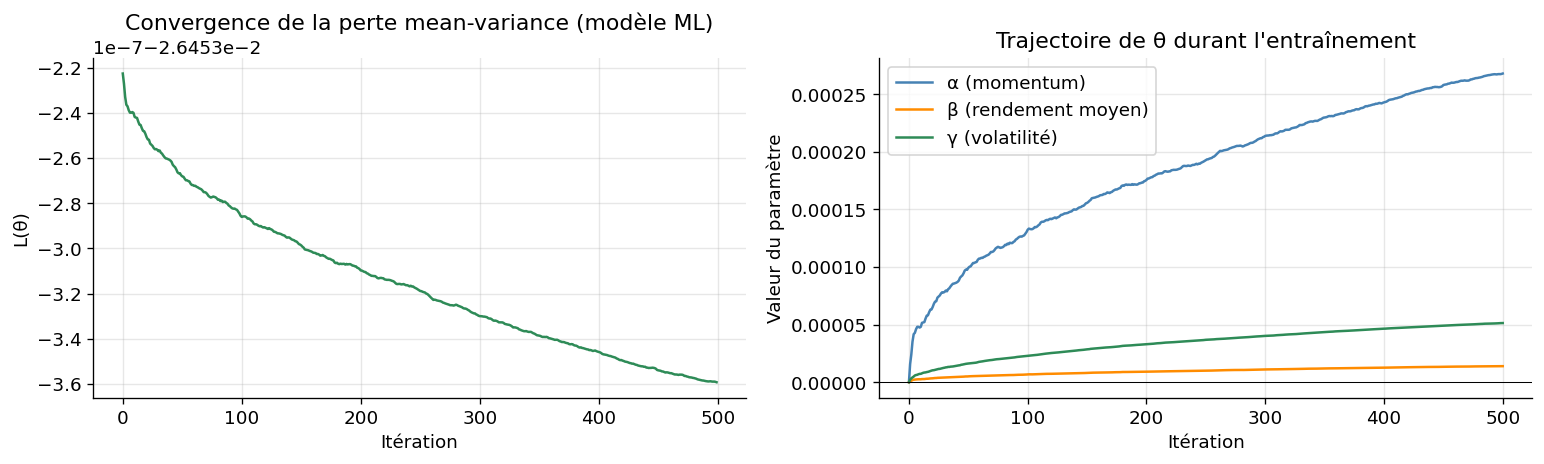

In [16]:
# ── Courbe de perte ML ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ml_result['loss_history'], color='seagreen', linewidth=1.5)
axes[0].set_title("Convergence de la perte mean-variance (modèle ML)")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("L(θ)")

# Évolution de θ
theta_hist = np.array(ml_result['theta_history'])
axes[1].plot(theta_hist[:, 0], label='α (momentum)', color='steelblue')
axes[1].plot(theta_hist[:, 1], label='β (rendement moyen)', color='darkorange')
axes[1].plot(theta_hist[:, 2], label='γ (volatilité)', color='seagreen')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_title("Trajectoire de θ durant l'entraînement")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Valeur du paramètre")
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
# ── Poids dynamiques sur données test ───────────────────────────────────────
# Générer les poids ML sur toute la période test avec θ appris sur train
prices_test_w = prices.loc[TEST_START:]
returns_test_w = returns.loc[TEST_START:]

ml_test = build_ml_signals(
    price_data        = prices_test_w,
    returns_data      = returns_test_w,
    window            = 20,
    method            = "momentum_volatility",
    long_only         = True,
    align_for_backtest = True,
    max_risky_weight  = 0.95,
)

weights_ml_test = ml_test['weights_for_backtest']
returns_ml_test = ml_test['returns_for_backtest']

print(f"Poids ML sur test : {len(weights_ml_test)} dates")
print(f"w_rf moyen         : {(1 - weights_ml_test.sum(axis=1)).mean():.3f}")
print(f"\nÉchantillon de poids ML (5 premières dates) :")
weights_ml_test.head().round(3)


Poids ML sur test : 509 dates
w_rf moyen         : 0.050

Échantillon de poids ML (5 premières dates) :


Ticker,MC.PA,RMS.PA,OR.PA,AIR.PA,SAN.PA,DG.PA,BNP.PA,ACA.PA,CS.PA,TTE.PA,EN.PA,VIE.PA,CAP.PA
Date,,,,,,,,,,,,,
2023-01-03,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073
2023-01-04,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073
2023-01-05,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073
2023-01-06,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073
2023-01-09,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073,0.073


## 6. Backtest et comparaison des stratégies

On évalue **quatre stratégies** sur la période de test (2023–2024) :

| Stratégie | Description |
|-----------|-------------|
| `equal_weight` | Équipondérée 1/N — benchmark de référence |
| `cash` | 100 % actif sans risque (r_f = 3 %) — plancher de performance |
| `optimized` | Poids statiques issus du SGD mean-variance avec cash |
| `dynamic` | Poids dynamiques issus du modèle ML (momentum/volatilité) |

> **Sharpe reporté ici** : Sharpe **ex-post** calculé sur les rendements **réalisés** du backtest.  
> À distinguer du Sharpe **ex-ante** de la Section 2 (calculé sur µ̂, Σ̂).


In [18]:
R_test = returns_test.to_numpy()

backtest = run_portfolio_backtest(
    returns_matrix          = returns_test,
    optimized_weights       = w_sgd,
    w_rf                    = w_rf_sgd,
    dynamic_weights         = weights_ml_test.reindex(returns_test.index).dropna(),
    initial_value           = 100.0,
    risk_free_rate          = RISK_FREE_RATE,
    annualization_factor    = ANNUALIZATION,
    include_cash_baseline   = True,
    equal_weight_risky_budget = 1.0,
    long_only               = True,
)

comparison = backtest['comparison'].copy()
comparison.columns.name = ''

# Formatage pour affichage
display_cols = ['cumulative_return','annualized_return','volatility','sharpe_ratio_expost','max_drawdown','avg_w_rf']
fmt = {
    'cumulative_return' : '{:.2%}',
    'annualized_return' : '{:.2%}',
    'volatility'        : '{:.2%}',
    'sharpe_ratio_expost': '{:.3f}',
    'max_drawdown'      : '{:.2%}',
    'avg_w_rf'          : '{:.3f}',
}
print("=== Tableau comparatif des stratégies — Backtest out-of-sample ===")
comparison[display_cols].style.format(fmt)


=== Tableau comparatif des stratégies — Backtest out-of-sample ===


,cumulative_return,annualized_return,volatility,sharpe_ratio_expost,max_drawdown,avg_w_rf
equal_weight,22.40%,10.51%,13.57%,0.665,-15.31%,0.000
cash,6.15%,2.99%,0.00%,0.000,0.00%,1.000
optimized,45.73%,20.45%,21.34%,0.887,-15.67%,0.000
dynamic,10.74%,5.18%,13.29%,0.242,-21.18%,0.050


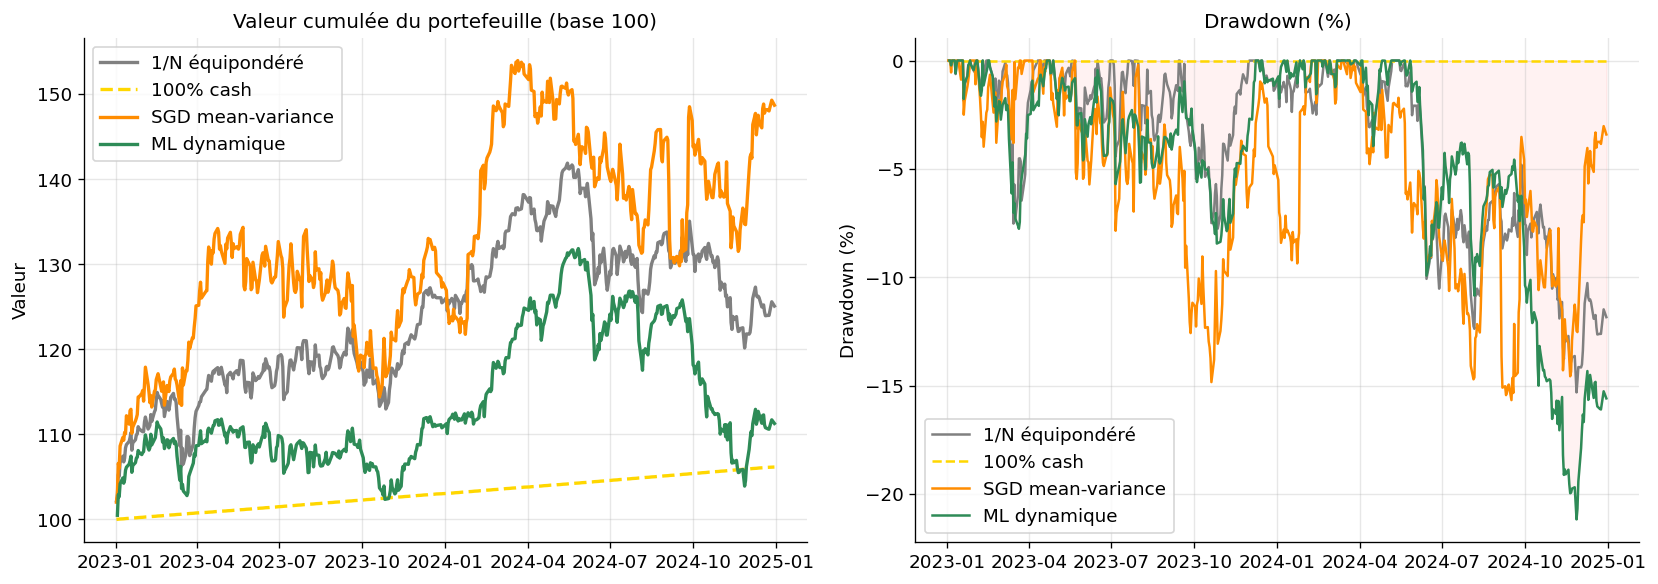

In [19]:
# ── Valeur cumulée des stratégies ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

strategy_names = ['equal_weight', 'cash', 'optimized', 'dynamic']
style_map = {
    'equal_weight': ('gray',       '-',  '1/N équipondéré'),
    'cash':         ('gold',       '--', '100% cash'),
    'optimized':    ('darkorange', '-',  'SGD mean-variance'),
    'dynamic':      ('seagreen',   '-',  'ML dynamique'),
}

for name in strategy_names:
    if name not in backtest['strategy_results']:
        continue
    res = backtest['strategy_results'][name]
    pv  = res['portfolio_value']
    color, ls, label = style_map[name]
    axes[0].plot(pv.index, pv, color=color, linestyle=ls, linewidth=2, label=label)

axes[0].set_title("Valeur cumulée du portefeuille (base 100)", fontsize=12)
axes[0].set_ylabel("Valeur")
axes[0].legend()

# ── Drawdown ────────────────────────────────────────────────────────────────
for name in strategy_names:
    if name not in backtest['strategy_results']:
        continue
    res = backtest['strategy_results'][name]
    pv  = res['portfolio_value']
    peak = pv.cummax()
    dd   = (pv - peak) / peak
    color, ls, label = style_map[name]
    axes[1].plot(dd.index, dd * 100, color=color, linestyle=ls, linewidth=1.5, label=label)

axes[1].fill_between(dd.index, dd * 100, 0, alpha=0.05, color='red')
axes[1].set_title("Drawdown (%)", fontsize=12)
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


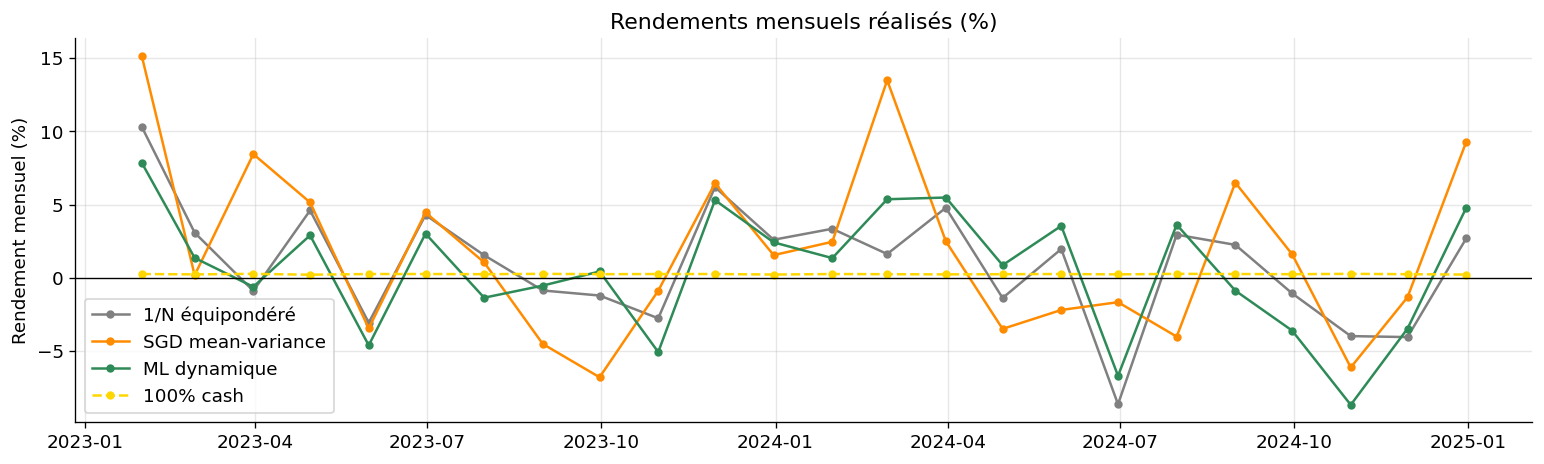

In [25]:
# ── Rendements mensuels rolling ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

for name in ['equal_weight', 'optimized', 'dynamic', 'cash']:
    if name not in backtest['strategy_results']:
        continue
    r = backtest['strategy_results'][name]['portfolio_returns']
    r_monthly = (1 + r).resample('ME').prod() - 1
    color, ls, label = style_map[name]
    ax.plot(r_monthly.index, r_monthly * 100, color=color, linestyle=ls,
            linewidth=1.5, marker='o', markersize=4, label=label)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Rendements mensuels réalisés (%)")
ax.set_ylabel("Rendement mensuel (%)")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Analyse de sensibilité

On étudie l'impact de deux hyperparamètres clés sur la performance out-of-sample :
- **λ** (aversion au risque) — arbitrage risque/rendement
- **`batch_size`** — niveau de bruit stochastique dans le gradient


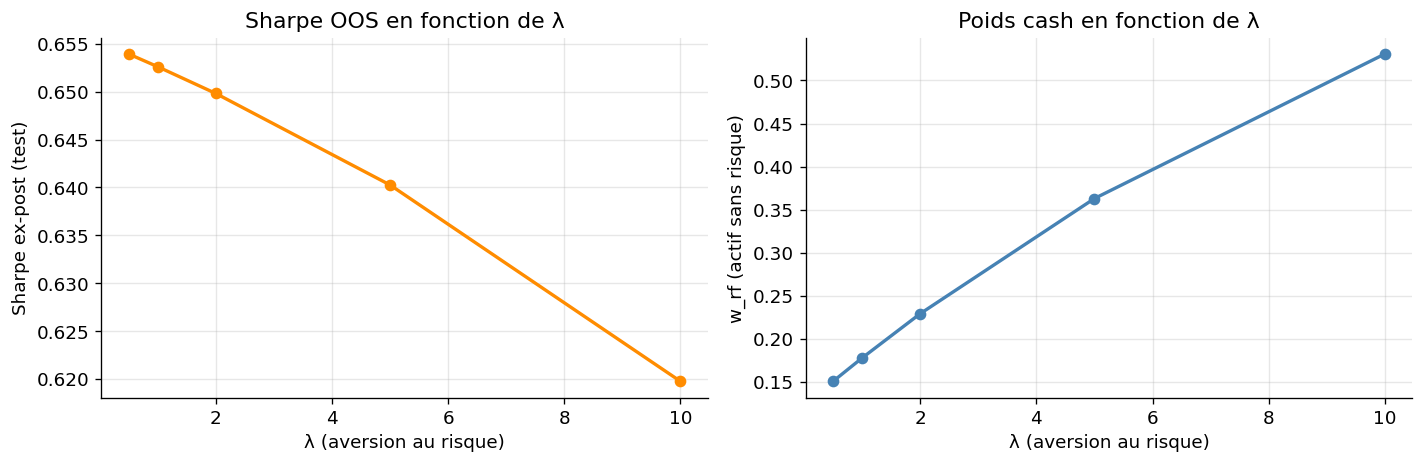

Interprétation : il existe généralement un λ optimal qui équilibre risque et rendement OOS.


In [21]:
# ── Sensibilité λ : backtest pour chaque λ ──────────────────────────────────
sharpe_oos_by_lambda = {}
wrf_oos_by_lambda    = {}

for lam in lambdas:
    w = sgd_results_lambda[lam]['final_weights']
    wrf = sgd_results_lambda[lam]['w_rf']
    res = run_portfolio_backtest(
        returns_matrix    = returns_test,
        optimized_weights = w,
        w_rf              = wrf,
        initial_value     = 100.0,
        risk_free_rate    = RISK_FREE_RATE,
        include_cash_baseline=False,
    )
    sharpe_oos_by_lambda[lam] = float(res['strategy_results']['optimized']['sharpe_ratio'])
    wrf_oos_by_lambda[lam]    = float(res['strategy_results']['optimized']['w_rf'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lambdas, [sharpe_oos_by_lambda[l] for l in lambdas], 'o-', color='darkorange', linewidth=2)
axes[0].set_xlabel("λ (aversion au risque)")
axes[0].set_ylabel("Sharpe ex-post (test)")
axes[0].set_title("Sharpe OOS en fonction de λ")

axes[1].plot(lambdas, [wrf_oos_by_lambda[l] for l in lambdas], 'o-', color='steelblue', linewidth=2)
axes[1].set_xlabel("λ (aversion au risque)")
axes[1].set_ylabel("w_rf (actif sans risque)")
axes[1].set_title("Poids cash en fonction de λ")

plt.tight_layout()
plt.show()
print("Interprétation : il existe généralement un λ optimal qui équilibre risque et rendement OOS.")


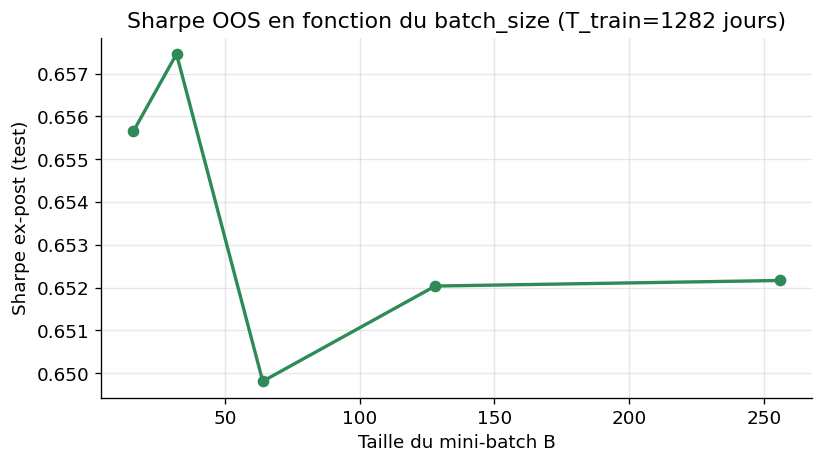

T_train = 1282 jours
  batch_size= 16 → 1.2% des données d'entraînement | Sharpe OOS = 0.656
  batch_size= 32 → 2.5% des données d'entraînement | Sharpe OOS = 0.657
  batch_size= 64 → 5.0% des données d'entraînement | Sharpe OOS = 0.650
  batch_size=128 → 10.0% des données d'entraînement | Sharpe OOS = 0.652
  batch_size=256 → 20.0% des données d'entraînement | Sharpe OOS = 0.652


In [22]:
# ── Sensibilité batch_size ──────────────────────────────────────────────────
batch_sizes = [16, 32, 64, 128, 256]
sharpe_by_batch = {}

for bs in batch_sizes:
    res = run_sgd(
        returns_matrix  = R_train,
        initial_weights = initialize_weights(N_ASSETS, method="equal", risky_budget=0.8),
        n_iterations    = 800,
        learning_rate   = 1e-3,
        lr_schedule     = "sqrt",
        lambda_risk     = LAMBDA,
        risk_free_rate  = RISK_FREE_RATE,
        use_cash        = True,
        batch_size      = bs,
        batch_shrinkage = 0.05,
        nonnegative     = True,
        exact_simplex   = True,
        random_state    = 42,
        verbose         = False,
    )
    w = res['final_weights']
    wrf = res['w_rf']
    bt = run_portfolio_backtest(
        returns_matrix=returns_test, optimized_weights=w, w_rf=wrf,
        initial_value=100.0, risk_free_rate=RISK_FREE_RATE, include_cash_baseline=False,
    )
    sharpe_by_batch[bs] = float(bt['strategy_results']['optimized']['sharpe_ratio'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(batch_sizes, [sharpe_by_batch[b] for b in batch_sizes], 'o-', color='seagreen', linewidth=2)
ax.set_xlabel("Taille du mini-batch B")
ax.set_ylabel("Sharpe ex-post (test)")
ax.set_title("Sharpe OOS en fonction du batch_size" + f" (T_train={len(R_train)} jours)")
plt.tight_layout()
plt.show()

T_train = len(R_train)
print(f"T_train = {T_train} jours")
for bs in batch_sizes:
    print(f"  batch_size={bs:3d} → {bs/T_train:.1%} des données d'entraînement | Sharpe OOS = {sharpe_by_batch[bs]:.3f}")


## 8. Synthèse et conclusions

### 8.1 Tableau récapitulatif final


In [23]:
# ── Tableau final complet ───────────────────────────────────────────────────
summary = comparison[display_cols].copy()
summary.index.name = 'Stratégie'
summary.columns = ['Rendement cumulé', 'Rendement ann.', 'Volatilité ann.',
                   'Sharpe ex-post', 'Max Drawdown', 'w_rf moyen']

print("=" * 80)
print("TABLEAU FINAL — Performance out-of-sample (2023–2024)")
print("=" * 80)
print(summary.to_string())
print()
print("Rappel :")
print("  Sharpe ex-post  = calculé sur les rendements RÉALISÉS (backtest)")
print("  w_rf moyen      = fraction moyenne allouée à l'actif sans risque")
print("  Max Drawdown    = perte maximale depuis un pic historique")


TABLEAU FINAL — Performance out-of-sample (2023–2024)
              Rendement cumulé  Rendement ann.  Volatilité ann.  Sharpe ex-post  Max Drawdown    w_rf moyen
Stratégie                                                                                                  
equal_weight          0.224044        0.105050         0.135735        0.664876     -0.153147  2.220446e-16
cash                  0.061522        0.029940         0.000000        0.000000      0.000000  1.000000e+00
optimized             0.457252        0.204496         0.213412        0.886507     -0.156712  0.000000e+00
dynamic               0.107365        0.051787         0.132916        0.242399     -0.211756  5.000000e-02

Rappel :
  Sharpe ex-post  = calculé sur les rendements RÉALISÉS (backtest)
  w_rf moyen      = fraction moyenne allouée à l'actif sans risque
  Max Drawdown    = perte maximale depuis un pic historique


### 8.2 Conclusions

#### Sur la cohérence mathématique
- La fonction de coût $J(w) = \lambda T w^\top \Sigma w - [T w^\top \mu + (1 - \mathbf{1}^\top w) r_f]$ est **homogène dimensionnellement** : tous les termes sont en rendement annuel.
- Le gradient $\nabla J = T(2\lambda \Sigma w - \mu) + r_f \mathbf{1}$ contient le terme $r_f \mathbf{1}$ qui force le SGD à n'allouer aux actifs risqués que si leur rendement **excède le taux sans risque**.
- La solution analytique $w^*$ de Markowitz est **indépendante de $T$** (le facteur disparaît dans les conditions du premier ordre) — ce qui est un résultat théorique important.

#### Sur le SGD
- Le schedule `sqrt` ($\eta_k = \eta_0/\sqrt{1+k}$) offre un bon compromis entre vitesse de convergence initiale et stabilité asymptotique.
- La ré-estimation stochastique de $\mu$ et $\Sigma$ sur des mini-batchs joue le rôle de régularisation implicite : les poids finaux sont moins sensibles aux fluctuations d'un estimateur calculé sur l'historique complet.

#### Sur l'extension ML
- Le modèle linéaire apprend une règle de pondération inter-actifs, **pas** un niveau d'exposition global au risque.
- La contrainte $\gamma \geq 0$ est une contrainte d'**interprétabilité économique**, pas d'optimalité mathématique.
- Les poids ML sont dynamiques et s'adaptent aux conditions de marché — avantage potentiel en période de forte dispersion sectorielle.

#### Limites du modèle
1. **Hypothèse gaussienne** : la kurtosis positive des rendements journaliers invalide partiellement l'hypothèse i.i.d. gaussienne.
2. **Stationnarité** : les paramètres $\mu$ et $\Sigma$ sont supposés constants sur la période d'entraînement — hypothèse forte sur 5 ans.
3. **Données simulées** : les résultats quantitatifs dépendent de la simulation ; les conclusions qualitatives (convergence du SGD, impact de $\lambda$) sont robustes.
4. **Biais look-ahead** : correctement traité via `align_weights_with_returns()`, mais la Σ ex-ante dans `run_static_backtest` utilise l'information future (mentionné à titre informatif uniquement).


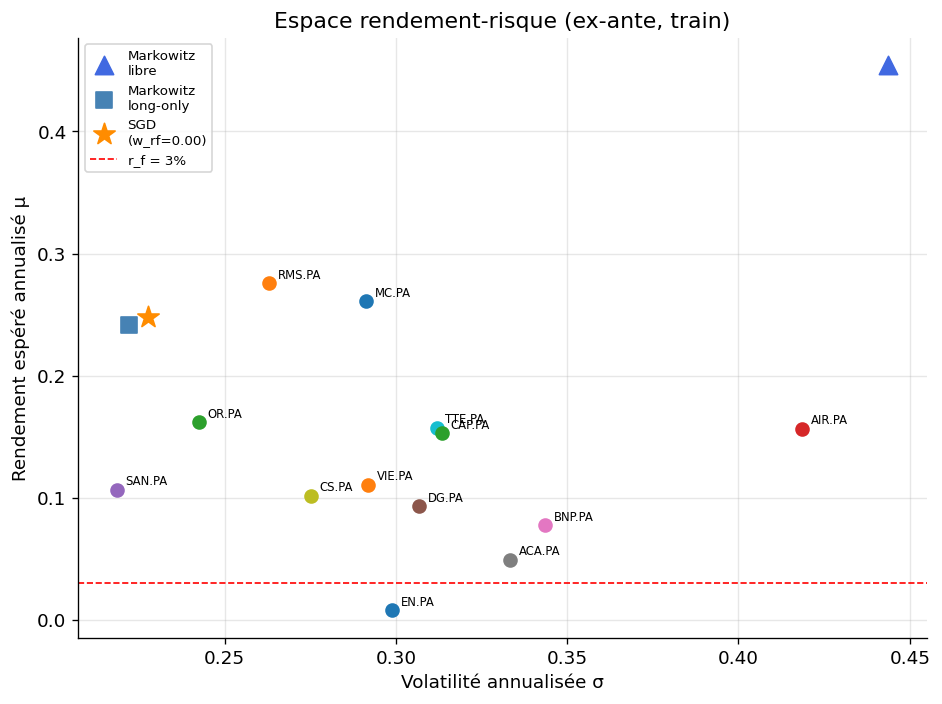

In [24]:
# ── Graphique final : espace rendement-risque ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Actifs individuels
for i, t in enumerate(TICKERS):
    ax.scatter(vol_ann[i], mu_ann[i], marker='o', s=60, 
               color=COLORS[i % 10], zorder=5)
    ax.annotate(t, (vol_ann[i], mu_ann[i]), 
                textcoords="offset points", xytext=(5, 3), fontsize=7)

# Portefeuilles
portfolios = {
    'Markowitz\nlibre'  : (w_markowitz_free, 'royalblue', '^', 120),
    'Markowitz\nlong-only': (w_markowitz_lo, 'steelblue', 's', 100),
    f'SGD\n(w_rf={w_rf_sgd:.2f})': (w_sgd,  'darkorange', '*', 180),
}
for label, (w, c, mk, ms) in portfolios.items():
    w_plot = np.clip(w, 0, None)
    vol_p = portfolio_volatility(w_plot, Sigma_hat) * np.sqrt(ANNUALIZATION)
    mu_p  = ANNUALIZATION * float(w_plot @ mu_hat)
    ax.scatter(vol_p, mu_p, marker=mk, s=ms, color=c, zorder=10, label=label)

ax.axhline(RISK_FREE_RATE, color='red', linestyle='--', linewidth=1,
           label=f'r_f = {RISK_FREE_RATE:.0%}')
ax.set_xlabel("Volatilité annualisée σ")
ax.set_ylabel("Rendement espéré annualisé μ")
ax.set_title("Espace rendement-risque (ex-ante, train)")
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()
